<a href="https://colab.research.google.com/github/tambevarad/Human-Speed-Detector/blob/master/Statistical_Arbitrage_Pairs_Trading_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Importing Required Libraries

In this step, we import the necessary Python libraries for our pairs trading strategy:

- **yfinance**: Used to download historical stock data.
- **numpy** and **pandas**: Essential for data manipulation and numerical operations.
- **statsmodels**: Provides tools for statistical analysis, including cointegration testing.
- **matplotlib**: Enables visualization of the data and strategy results.
- **scipy**: Contains statistical functions for hypothesis testing, such as the cointegration test.


In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

### Step 2: Fetching Stock Data

In this step, we select two historically correlated stocks—PepsiCo (PEP) and Coca-Cola (KO). Both companies operate in the beverage industry, making them suitable candidates for a pairs trading strategy based on their similar market behavior.


In [7]:
# Explicitly disable auto_adjust to get 'Adj Close' column
data = yf.download(['PEP', 'KO'], start='2015-01-01', end='2023-01-01', auto_adjust=False)

# If you want Adjusted Close prices:
adj_close = data['Adj Close']

# Preview
print(adj_close.head())


[*********************100%***********************]  2 of 2 completed

Ticker             KO        PEP
Date                            
2015-01-02  30.222609  69.219109
2015-01-05  30.222609  68.698753
2015-01-06  30.452120  68.178329
2015-01-07  30.832235  70.171928
2015-01-08  31.205183  71.447281


### Step 3: Testing for Cointegration

Cointegration is a key concept in pairs trading. It tests whether two asset prices move together over the long term, meaning their price relationship is stable and tends to revert to the mean.

To verify this, we use the **Augmented Dickey-Fuller (ADF) test**, which helps determine if the spread between the two assets is stationary—an essential condition for pairs trading.


In [9]:
from statsmodels.tsa.stattools import coint

# Correct: use `adj_close`, not `data`
score, p_value, _ = coint(adj_close['PEP'], adj_close['KO'])

print(f'Cointegration test p-value: {p_value}')

if p_value < 0.05:
    print("The pairs are cointegrated.")
else:
    print("The pairs are not cointegrated.")


Cointegration test p-value: 0.012414707134634377
The pairs are cointegrated.


### Step 4: Calculating the Spread

The **spread** is simply the difference between the prices of the two stocks in our pair. Monitoring this spread helps us identify when the prices diverge from their typical relationship.

When the spread deviates significantly from its mean, it signals potential trading opportunities — buying the undervalued stock and shorting the overvalued one.

Below is how we calculate the spread:


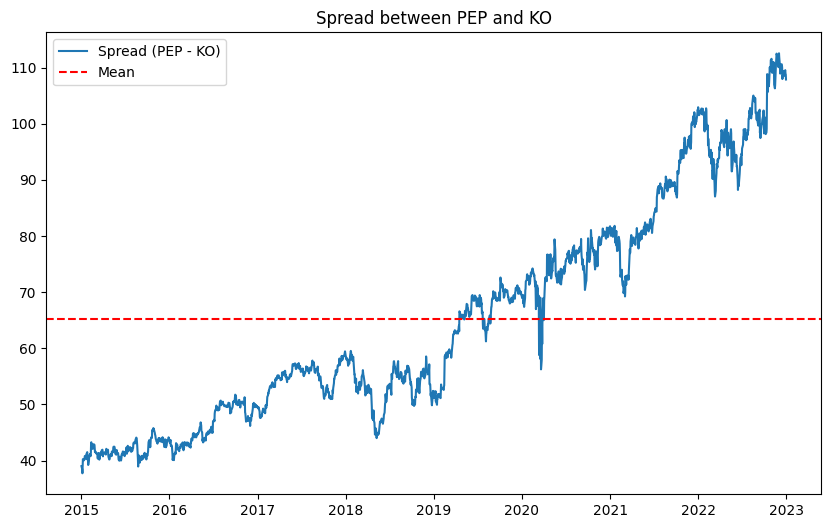

In [12]:
# Calculate the spread
adj_close.loc[:, 'Spread'] = adj_close['PEP'] - adj_close['KO']

# Plot the spread
plt.figure(figsize=(10, 6))
plt.plot(adj_close.index, adj_close['Spread'], label='Spread (PEP - KO)')
plt.axhline(adj_close['Spread'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.title('Spread between PEP and KO')
plt.show()

### Step 5: Implementing the Pairs Trading Strategy

We implement a simple trading strategy based on the spread behavior:

- **Go long on the pair** (buy PepsiCo, sell Coca-Cola) when the spread falls **below** a lower threshold (mean minus threshold).
- **Go short on the pair** (sell PepsiCo, buy Coca-Cola) when the spread rises **above** an upper threshold (mean plus threshold).
- **Exit the position** when the spread reverts back toward the mean.

This approach capitalizes on the tendency of the spread to revert to its average over time.


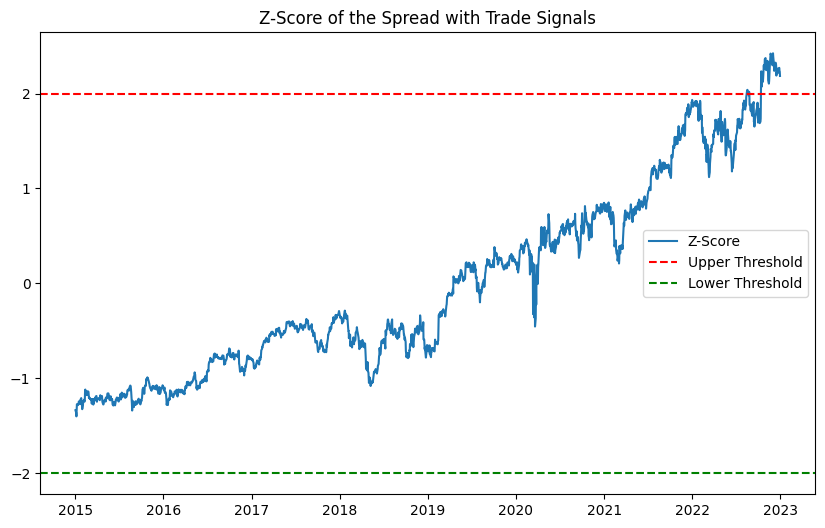

In [18]:
# Make sure adj_close is a fresh copy to avoid SettingWithCopyWarning
adj_close = data['Adj Close'].copy()

# Calculate Spread (if not done yet)
adj_close.loc[:, 'Spread'] = adj_close['PEP'] - adj_close['KO']

# Define z-score on adj_close
adj_close.loc[:, 'Z-Score'] = (adj_close['Spread'] - adj_close['Spread'].mean()) / adj_close['Spread'].std()

# Set thresholds
upper_threshold = 2
lower_threshold = -2

# Initialize and generate trading signals
adj_close.loc[:, 'Position'] = 0
adj_close.loc[:, 'Position'] = np.where(adj_close['Z-Score'] > upper_threshold, -1, adj_close['Position'])  # Short
adj_close.loc[:, 'Position'] = np.where(adj_close['Z-Score'] < lower_threshold, 1, adj_close['Position'])   # Long
adj_close.loc[:, 'Position'] = np.where((adj_close['Z-Score'] < 1) & (adj_close['Z-Score'] > -1), 0, adj_close['Position'])  # Exit

# Plot Z-score and thresholds
plt.figure(figsize=(10, 6))
plt.plot(adj_close.index, adj_close['Z-Score'], label='Z-Score')
plt.axhline(upper_threshold, color='red', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='green', linestyle='--', label='Lower Threshold')
plt.legend()
plt.title('Z-Score of the Spread with Trade Signals')
plt.show()


### Step 6: Backtesting the Strategy

In this step, we backtest our pairs trading strategy by simulating trades over historical data.

We assume equal dollar amounts are allocated to each leg of the pair (long and short positions), and we calculate the strategy’s returns over time to evaluate its performance.


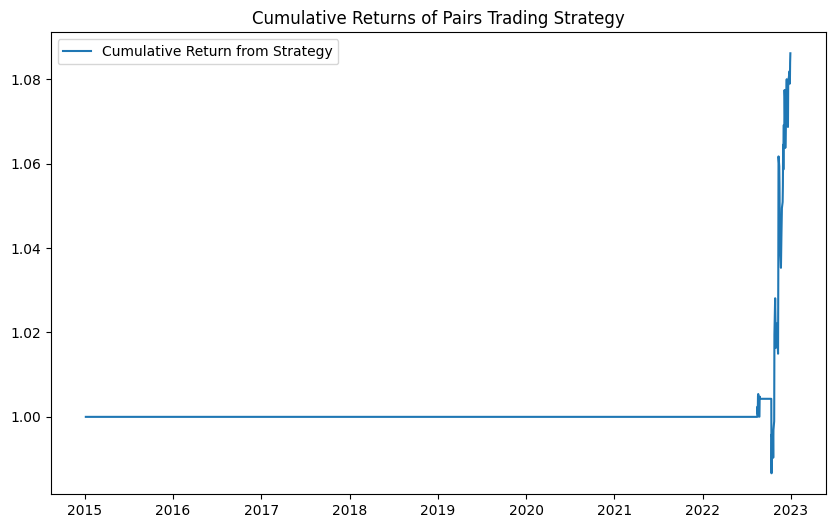

In [19]:
# Create final working DataFrame for strategy calculations
strategy_df = adj_close.copy()

# Calculate daily returns
strategy_df.loc[:, 'PEP_Return'] = strategy_df['PEP'].pct_change()
strategy_df.loc[:, 'KO_Return'] = strategy_df['KO'].pct_change()

# Strategy returns
strategy_df.loc[:, 'Strategy_Return'] = strategy_df['Position'].shift(1) * (strategy_df['PEP_Return'] - strategy_df['KO_Return'])

# Cumulative returns
strategy_df.loc[:, 'Cumulative_Return'] = (1 + strategy_df['Strategy_Return']).cumprod()

# Plot cumulative returns
plt.figure(figsize=(10, 6))
plt.plot(strategy_df.index, strategy_df['Cumulative_Return'], label='Cumulative Return from Strategy')
plt.title('Cumulative Returns of Pairs Trading Strategy')
plt.legend()
plt.show()


### Step 7: Strategy Evaluation

To assess how well our pairs trading strategy performs, we calculate key metrics including:

- **Sharpe Ratio**: Measures risk-adjusted return by comparing the strategy’s excess returns to its volatility.
- **Maximum Drawdown**: Indicates the largest peak-to-trough decline in the strategy’s cumulative returns, measuring downside risk.
- **Annualized Return**: Represents the compounded return achieved by the strategy on a yearly basis.

These metrics provide a comprehensive view of both the profitability and risk characteristics of the strategy.


In [21]:
sharpe_ratio = strategy_df['Strategy_Return'].mean() / strategy_df['Strategy_Return'].std() * np.sqrt(252)
print(f'Sharpe Ratio: {sharpe_ratio:.4f}')

cumulative_max = strategy_df['Cumulative_Return'].cummax()
drawdown = (cumulative_max - strategy_df['Cumulative_Return']) / cumulative_max
max_drawdown = drawdown.max()
print(f'Max Drawdown: {max_drawdown:.4f}')

Sharpe Ratio: 0.5368
Max Drawdown: 0.0249


## Explanations and Use Cases

1. **Cointegration Test:**  
   - **Explanation:** The cointegration test checks whether two assets share a long-term equilibrium relationship. A low p-value indicates that the prices of PepsiCo (PEP) and Coca-Cola (KO) move together over time, making them suitable for pairs trading.  
   - **Use Case:** This step is critical because pairs trading works reliably only when the two securities are cointegrated. Without cointegration, the relationship between prices may break down, causing losses.

2. **Spread Calculation:**  
   - **Explanation:** The spread is the price difference between the two assets. Calculating the mean and standard deviation of the spread helps identify when the spread deviates significantly from its average.  
   - **Use Case:** Monitoring the spread allows us to detect trading signals. When the spread widens (diverges), we trade on the assumption it will revert to the mean.

3. **Trading Strategy (Z-Score):**  
   - **Explanation:** The Z-score normalizes the spread to quantify deviations from its mean. By defining thresholds on the Z-score, we automate the process of entering long or short positions when the spread is significantly away from average.  
   - **Use Case:** Using the Z-score enables systematic generation of buy and sell signals, reducing reliance on subjective judgment.

4. **Backtesting:**  
   - **Explanation:** Backtesting simulates how the strategy would have performed on historical data. Performance metrics like cumulative return, Sharpe ratio, and maximum drawdown provide insights into profitability and risk.  
   - **Use Case:** Backtesting is essential to evaluate the viability of the strategy before deploying it in live markets.

---

## Summary

This pairs trading strategy uses Python to implement statistical arbitrage by exploiting the cointegration between two stocks, PEP and KO. By calculating the spread and monitoring its deviations using Z-scores, the strategy systematically enters and exits trades.

Backtesting on historical data helps assess the effectiveness of the approach.

Potential enhancements include position sizing based on volatility, factoring in transaction costs, or incorporating machine learning methods to better predict mean reversion.

